<a href="https://colab.research.google.com/github/VivekOPest/gaia-symbolic-regression/blob/main/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaia Symbolic Regression
## Data Acquisition and Exploratory Data Analysis

This notebook loads a curated sample from Gaia DR3, performs exploratory data analysis, derives additional physical quantities, and prepares the dataset for symbolic regression.

In [20]:
# ===========================
# Import Libraries
# ===========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

# Make plots look nicer
plt.style.use("ggplot")

In [22]:
# ===========================
# Load Dataset
# ===========================

DATA_PATH = "gaia_sample.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [23]:
# First five rows

df.head()

,source_id,parallax,parallax_error,parallax_over_error,ruwe,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,teff_gspphot,radius_gspphot
0,137341754068386432,0.933154,0.051944,17.964705,1.036885,16.108717,16.661566,15.408920,1.252646,4896.8936,0.8375
1,137342166385242112,4.299332,0.022674,189.618150,1.026791,14.220328,15.037620,13.338170,1.699450,4397.8647,0.7090
2,137348900893898240,0.796858,0.042952,18.552425,1.002285,15.707364,16.114141,15.123431,0.990710,5307.8760,0.7948
3,137351615313312384,1.354746,0.018821,71.981310,1.202068,12.139791,12.538257,11.568266,0.969991,5952.5596,2.3795
4,137355326165033472,1.222841,0.056203,21.757740,1.006233,16.461163,17.241302,15.604395,1.636908,4525.4976,0.8585


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   source_id            20000 non-null  int64  
 1   parallax             20000 non-null  float64
 2   parallax_error       20000 non-null  float64
 3   parallax_over_error  20000 non-null  float64
 4   ruwe                 20000 non-null  float64
 5   phot_g_mean_mag      20000 non-null  float64
 6   phot_bp_mean_mag     20000 non-null  float64
 7   phot_rp_mean_mag     20000 non-null  float64
 8   bp_rp                20000 non-null  float64
 9   teff_gspphot         20000 non-null  float64
 10  radius_gspphot       20000 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 1.7 MB


In [25]:
df.describe()

,source_id,parallax,parallax_error,parallax_over_error,ruwe,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,teff_gspphot,radius_gspphot
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,1.602778e+17,1.375141,0.055600,34.773441,1.028474,15.541746,16.198532,14.799265,1.399267,5137.109465,1.596792
std,3.029356e+16,1.255696,0.043833,47.910537,0.078628,1.595602,1.848922,1.460491,0.571870,1123.945195,6.192113
min,1.373330e+17,0.159441,0.011025,10.000620,0.779924,6.294179,6.599994,5.578552,-0.060136,2725.162400,0.152300
25%,1.395227e+17,0.676396,0.026967,13.533041,0.979443,14.625136,15.081946,14.007751,0.994104,4458.739700,0.667175
50%,1.416799e+17,0.991120,0.041557,20.131662,1.016630,15.643333,16.145353,14.974376,1.219895,5140.719700,0.860800
75%,1.980381e+17,1.632212,0.066693,36.128230,1.063264,16.601764,17.321475,15.790983,1.642462,5756.013750,1.275725
max,2.124105e+17,27.334787,0.401105,1240.783300,1.398688,18.999926,21.255259,17.841698,4.945676,34999.370000,608.047700


In [26]:
df.isnull().sum()

,0
source_id,0
parallax,0
parallax_error,0
parallax_over_error,0
ruwe,0
phot_g_mean_mag,0
phot_bp_mean_mag,0
phot_rp_mean_mag,0
bp_rp,0
teff_gspphot,0


In [27]:
print(df.columns.tolist())

['source_id', 'parallax', 'parallax_error', 'parallax_over_error', 'ruwe', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp', 'teff_gspphot', 'radius_gspphot']


In [28]:
corr = df.corr(numeric_only=True)

corr["radius_gspphot"].sort_values(ascending=False)

,radius_gspphot
radius_gspphot,1.000000
ruwe,0.086190
source_id,0.046593
bp_rp,0.040788
teff_gspphot,0.029403
parallax_over_error,-0.017396
parallax,-0.097080
parallax_error,-0.119261
phot_bp_mean_mag,-0.213116
phot_g_mean_mag,-0.257248


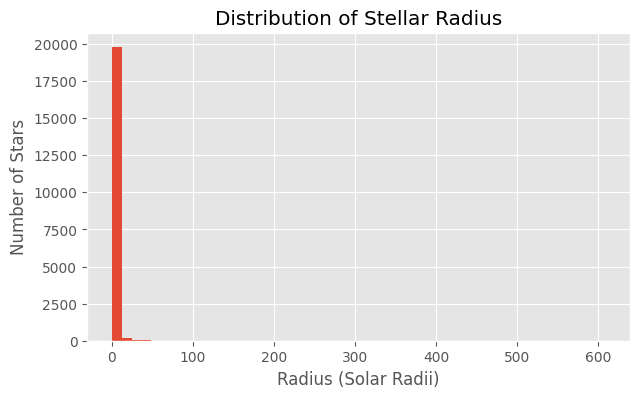

In [29]:
plt.figure(figsize=(7,4))

plt.hist(df["radius_gspphot"], bins=50)

plt.xlabel("Radius (Solar Radii)")
plt.ylabel("Number of Stars")
plt.title("Distribution of Stellar Radius")

plt.show()

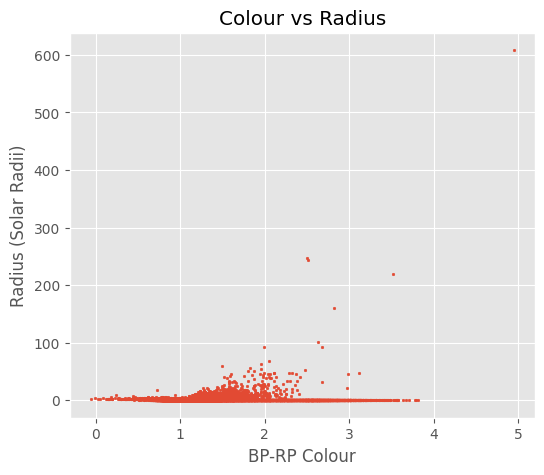

In [30]:
plt.figure(figsize=(6,5))

plt.scatter(
    df["bp_rp"],
    df["radius_gspphot"],
    s=3
)

plt.xlabel("BP-RP Colour")
plt.ylabel("Radius (Solar Radii)")
plt.title("Colour vs Radius")

plt.show()

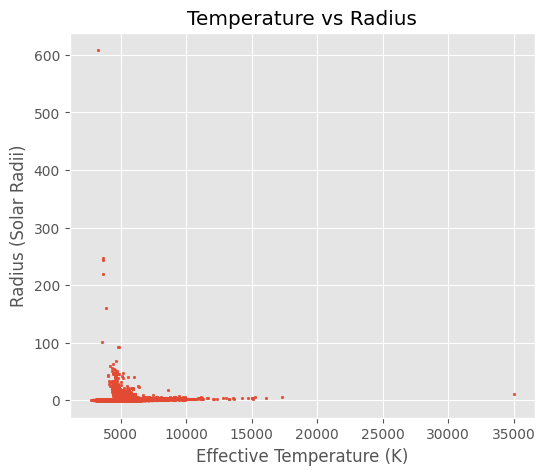

In [31]:
plt.figure(figsize=(6,5))

plt.scatter(
    df["teff_gspphot"],
    df["radius_gspphot"],
    s=3
)

plt.xlabel("Effective Temperature (K)")
plt.ylabel("Radius (Solar Radii)")
plt.title("Temperature vs Radius")

plt.show()